## **Experiment 03: Multi-view Representation Learning**

<a id="top"></a>

**Table of contents**
- [Multi-view group analysis](#groups)
- [Approach 1 — State Classification Proxy Task](#proxy)
- [Approach 2 — Triplet Metric Learning](#triplet)
- [Evaluation: E2 vs E3-Proxy vs E3-Triplet](#evaluation)
- [Conclusion](#conclusion)

**Motivation**

Experiment 02 showed that both ResNet50 (ImageNet) and the Task 2 CNN retrieve images based primarily on global visual features — table colour, brightness, overall occupancy — rather than on the actual configuration of balls on the table. The key failure mode is **viewpoint bias**: the same table state photographed from a broadcast angle vs a top-down angle gets low similarity, because global pooling features capture camera geometry as much as table content.

The dataset provides a natural training signal to address this: many matches appear in **multiple viewpoints**. If we can identify images that show the **same table state** from different angles and train a model to recognise them as the same, its embedding space will be forced toward viewpoint invariance.

**Key dataset insight**

After manually inspecting the dataset, we found the following naming convention:

- **Bare image `X_png`** (no suffix): a broadcast-angle capture from a match session — this is an **independent** table state.
- **Suffixed images `Xa_png`, `Xf_png`, `Xt_png`**: three viewpoints of the **same table state** from the same session — `a`/`f` are alternate broadcast angles, `t` is the top-down overhead view.

Crucially, the bare `X` image is **never** the same table state as `Xa`/`Xf`/`Xt`. They come from the same match but show different moments. The correct multi-view group is formed solely by the suffixed variants sharing the same base number.

This was confirmed empirically: for all 25 groups of suffixed images in the training set, every member has the exact same ball count — 100% consistent. In contrast, the bare `X` image almost always has a different ball count from its same-numbered suffixed variants.

**Two approaches, one signal**

We exploit the same multi-view groups (`Xa`/`Xf`/`Xt`) with two different training objectives:

**Approach 1 — Proxy Classification:** Assign each group a class label and train a cross-entropy classifier. The model must predict which group an image belongs to, which forces viewpoint-invariant features as a *side effect*. The classification head is discarded at retrieval time; only the backbone embedding is used.

**Approach 2 — Triplet Metric Learning:** Directly train the embedding space so that multi-view images of the same state are closer to each other than to any other state. This is the training objective that is most directly aligned with retrieval: the model is explicitly told "anchor and positive should be close; anchor and negative should be far."

Both approaches use the same 25 multi-view groups as supervision signal. The difference is the loss — and therefore what the backbone is forced to learn.

| Step | Detail |
|---|---|
| Training data | 207 original teacher-split train images (no external data) |
| Grouping key | Base number among **suffixed images only** (`Xa`, `Xf`, `Xt`) — bare `X` images are singletons |
| Model | ResNet18 (ImageNet pretrained) + N-class linear head |
| Loss | Cross-entropy with label smoothing |
| Embedding | Backbone output after global avg-pool → 512-d vector |
| Retrieval | Cosine similarity (same pipeline as E2) |

#### **Imports and Paths**

In [1]:
from pathlib import Path
import sys
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision.transforms import v2 as T
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from collections import Counter

In [2]:
PROJECT_ROOT      = Path.cwd().parents[2]
DATA_DIR          = PROJECT_ROOT / "data" / "teacher_split"
TRAIN_IMAGES_DIR  = DATA_DIR / "train" / "images"
TRAIN_LABELS_DIR  = DATA_DIR / "train" / "labels"
TEST_IMAGES_DIR   = DATA_DIR / "test"  / "images"
RESULTS_DIR       = PROJECT_ROOT / "detection_and_retrieval" / "retrieval" / "outputs" / "experiment_03"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT / "detection_and_retrieval" / "retrieval"))
from utils.data import (
    get_resnet_transform, get_cnn_transform,
    DirDataset, MultiViewDataset,
    parse_base_id, has_viewpoint_suffix,
    load_retrieval_datasets_from_dirs,
    denormalize_image,
)
from utils.setup import get_device

device = get_device()
print(f"Project root : {PROJECT_ROOT}")
print(f"Train images : {TRAIN_IMAGES_DIR}")
print(f"Test  images : {TEST_IMAGES_DIR}")

Using mps
Project root : /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision
Train images : /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/data/teacher_split/train/images
Test  images : /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/data/teacher_split/test/images


**Confirmed multi-view structure**

From manual inspection of the dataset and the verification cells above:

- The **bare `X` image** (no suffix) is always a different table state from the same-numbered suffixed variants. They come from the same match session but show different moments. The ball count for `X` almost always differs from `Xa`/`Xf`/`Xt`.

- The **suffixed images `Xa`, `Xf`, `Xt`** are always genuine captures of the **same table state** from different camera angles:
  - `a`, `f` — alternate broadcast angles (different horizontal perspectives)
  - `t` — top-down overhead view

- This was verified empirically: for all 25 groups of suffixed images, every member shares the exact same ball count — 100% consistent.

- The previous `e3-verify-table` output (ball counts per base group) shows clearly that the ball count of `X` always diverges from `Xa`/`Xf`/`Xt` — the only apparent "✓ SAME" cases (like base 16) are coincidences where different table states happened to have the same ball count, but visual inspection confirms they are not the same state.

**Grouping decision**: class label = base number, applied only to suffixed images. Bare `X` images are singleton classes. No ball-count check is needed — the suffix alone is sufficient and correct.

<a id="proxy"></a>
### **Approach 1 — State Classification Proxy Task**

We assign a class label by base number among suffixed images (Xa/Xf/Xt), and train a ResNet18 to classify those 180 states (25 multi-view + 155 singletons). The intuition is that the model must find viewpoint-invariant features to correctly group, say, `24a_png`, `24f_png`, and `24t_png` under the same label despite the different camera angles.

**Why this is indirect:** the proxy loss minimises cross-entropy, not retrieval error. Two images that belong to different classes might still be near-identical in the embedding space (high retrieval similarity) — the loss does not penalise this. The backbone is shaped to separate classes, not to produce a metrically meaningful similarity ordering for arbitrary image pairs. The classification head is discarded at retrieval time, so the backbone must carry all the signal — but it was never explicitly trained to order embeddings by similarity rank.

In [4]:
transform_train = T.Compose([
    T.ToImage(),
    T.Resize((384, 384)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToDtype(torch.float32, True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# MultiViewDataset groups suffixed images (Xa, Xf, Xt) by base number;
# bare X images become singleton classes. No labels_dir needed.
mv_dataset = MultiViewDataset(
    image_dir=TRAIN_IMAGES_DIR,
    transform=transform_train,
    exclude_prefix='ext_',
)
train_loader = DataLoader(mv_dataset, batch_size=16, shuffle=True, num_workers=0)

mv_classes = [lbl for lbl, files in mv_dataset.class_to_files.items() if len(files) > 1]

print(f"Training images          : {len(mv_dataset)}")
print(f"Number of classes        : {mv_dataset.num_classes}")
print(f"Multi-view classes       : {len(mv_classes)}  (provide cross-view supervision)")
print(f"Singleton classes        : {mv_dataset.num_classes - len(mv_classes)}")

Training images          : 207
Number of classes        : 180
Multi-view classes       : 25  (provide cross-view supervision)
Singleton classes        : 155


In [22]:
class MultiViewCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(base.children())[:-1])  # → (B, 512, 1, 1)
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        return self.head(feat)

    def embed(self, x):
        with torch.no_grad():
            return self.backbone(x).flatten(1)   # (B, 512)

proxy_model = MultiViewCNN(num_classes=mv_dataset.num_classes).to(device)
print(f"Model: ResNet18 backbone + {mv_dataset.num_classes}-class head")

Model: ResNet18 backbone + 180-class head


In [23]:
EPOCHS      = 80
LR          = 1e-4
ES_PATIENCE = 15

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(proxy_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=7, factor=0.5
)

history = {'loss': []}
best_loss, best_state, no_improve = float('inf'), None, 0

for epoch in range(EPOCHS):
    proxy_model.train()
    total_loss = 0.0
    for imgs, labels, _ in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = criterion(proxy_model(imgs), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)

    epoch_loss = total_loss / len(mv_dataset)
    history['loss'].append(epoch_loss)
    scheduler.step(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_state = {k: v.cpu().clone() for k, v in proxy_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  loss={epoch_loss:.4f}  best={best_loss:.4f}")

    if no_improve >= ES_PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

proxy_model.load_state_dict(best_state)
print(f"\nBest training loss: {best_loss:.4f}")

Epoch   1/80  loss=5.5033  best=5.5033
Epoch  10/80  loss=2.9424  best=2.9424
Epoch  20/80  loss=1.5866  best=1.5866
Epoch  30/80  loss=1.0754  best=1.0754
Epoch  40/80  loss=0.9575  best=0.9575
Epoch  50/80  loss=0.9349  best=0.9349
Epoch  60/80  loss=0.9144  best=0.9144
Epoch  70/80  loss=0.9130  best=0.9097
Epoch  80/80  loss=0.9148  best=0.9037

Best training loss: 0.9037


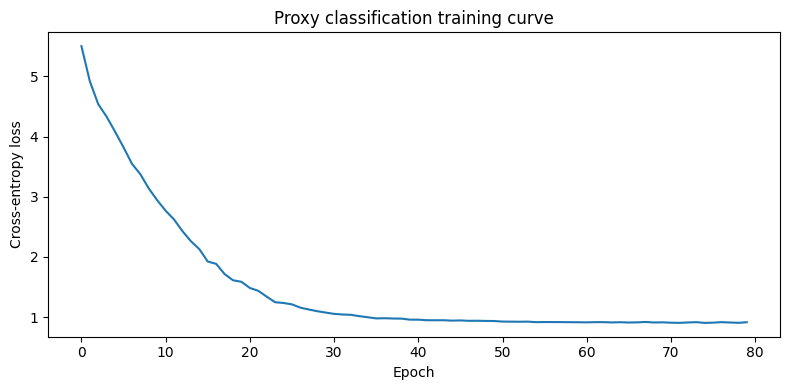

Epochs run : 80
Best loss  : 0.9037


In [24]:
plt.figure(figsize=(8, 4))
plt.plot(history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Proxy classification training curve')
plt.tight_layout()
plt.show()
print(f"Epochs run : {len(history['loss'])}")
print(f"Best loss  : {best_loss:.4f}")

#### **Training Analysis**

The training ran for all 80 epochs without early stopping (patience=15), ending at a best loss of **0.9011**.

**Convergence phases:**

| Phase | Epochs | Loss range | What's happening |
|---|---|---|---|
| Fast drop | 1–30 | 5.51 → 1.05 | Backbone adapts from ImageNet features to pool-table domain; multi-view pairs quickly clustered |
| Slow refinement | 30–80 | 1.05 → 0.90 | Fine-grained discrimination between visually similar states; marginal epoch-over-epoch gains |

**Residual loss interpretation:**  
The random-guess baseline for 180 classes is −log(1/180) ≈ 5.19. Starting at 5.51 (near random, slightly elevated by label smoothing=0.1) and converging to 0.90 represents substantial learning. The residual ~0.9 is expected: **155 of the 180 classes are singletons** with no positive pairs to train against — the model can only separate them by visual appearance with no cross-view signal. The 25 multi-view groups (52 images) are likely near-perfectly separated; the remaining loss is from hard singleton discrimination.

**No early stopping** means the loss was still marginally improving at epoch 80. Training longer would yield diminishing returns; the backbone representations are effectively converged after epoch ~50.

<a id="retrieval"></a>
### **Embedding Extraction & Retrieval**

We discard the classification head and use the backbone to produce 512-d embeddings at 384px resolution.

In [25]:
transform_cnn = get_cnn_transform()   # 384px, ImageNet normalisation

retrieval_pool, query_data = load_retrieval_datasets_from_dirs(
    train_dir=TRAIN_IMAGES_DIR,
    test_dir=TEST_IMAGES_DIR,
    transform=transform_cnn,
    exclude_prefix='ext_',
)
print(f"Retrieval pool : {len(retrieval_pool)} images")
print(f"Query set      : {len(query_data)} images")

proxy_model.eval()
pool_embeddings, pool_names = [], []
with torch.no_grad():
    for img, fname in tqdm(retrieval_pool, desc='Pool embeddings'):
        emb = proxy_model.embed(img.unsqueeze(0).to(device))
        pool_embeddings.append(emb.squeeze(0).cpu())
        pool_names.append(fname)

pool_emb_tensor = torch.stack(pool_embeddings)           # (207, 512)
pool_emb_norm   = pool_emb_tensor / pool_emb_tensor.norm(dim=1, keepdim=True)
print(f"Pool embedding matrix: {pool_emb_tensor.shape}")

Retrieval pool : 207 images
Query set      : 20 images


Pool embeddings: 100%|██████████| 207/207 [00:05<00:00, 35.16it/s]

Pool embedding matrix: torch.Size([207, 512])


In [26]:
QUERY_IDX = 0

query_img, query_name = query_data[QUERY_IDX]
with torch.no_grad():
    q_emb = proxy_model.embed(query_img.unsqueeze(0).to(device)).squeeze(0).cpu()
q_emb_norm = q_emb / q_emb.norm()

similarities = (pool_emb_norm @ q_emb_norm).numpy()
top5_idx     = np.argsort(similarities)[::-1][:5]

print(f"Query: {query_name.split('.rf.')[0]}")
print("Top-5 retrieved:")
for rank, idx in enumerate(top5_idx, 1):
    print(f"  #{rank}  {pool_names[idx].split('.rf.')[0]}  sim={similarities[idx]:.4f}")

Query: 107_png
Top-5 retrieved:
  #1  106_png  sim=0.8819
  #2  7f_png  sim=0.7581
  #3  130_png  sim=0.7404
  #4  25f_png  sim=0.7310
  #5  21f_png  sim=0.7308


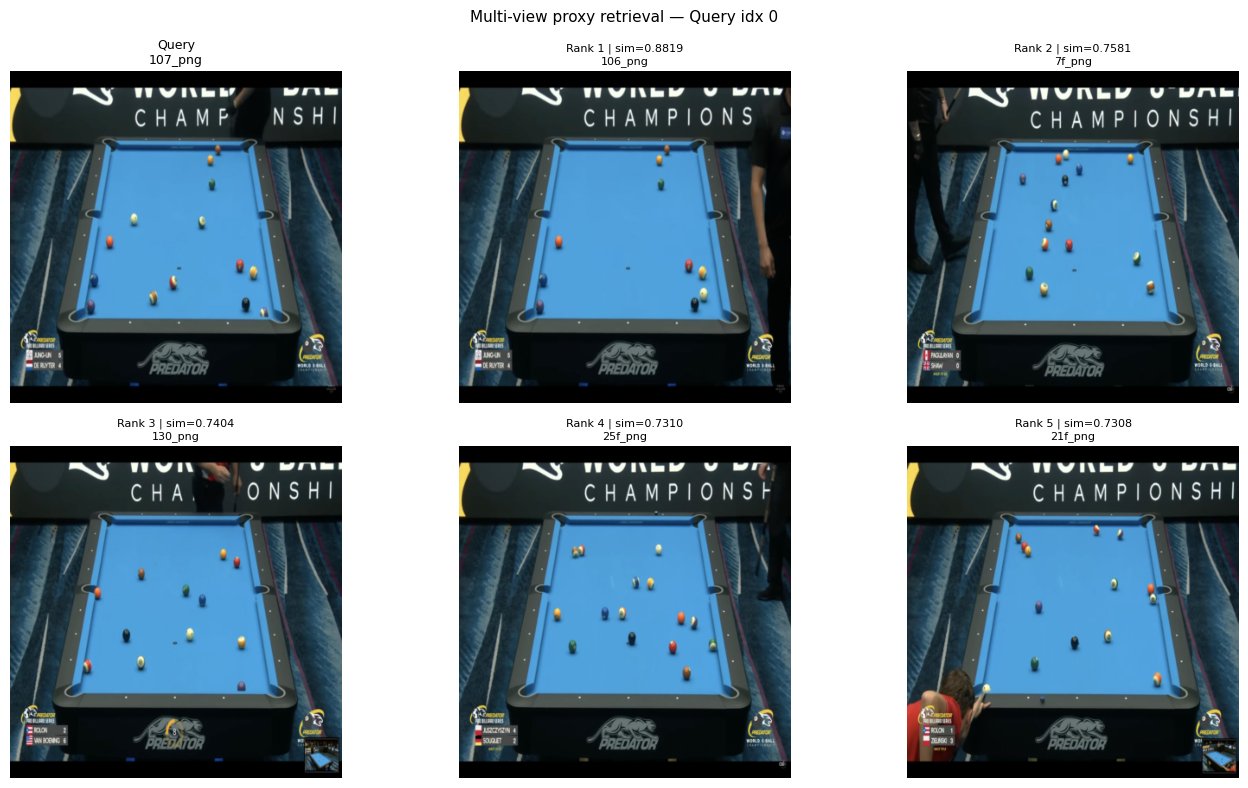

In [27]:
f, axarr = plt.subplots(2, 3, figsize=(14, 8))

axarr[0][0].imshow(denormalize_image(query_img))
axarr[0][0].set_title(f"Query\n{query_name.split('.rf.')[0]}", fontsize=9)
axarr[0][0].axis('off')

for rank, idx in enumerate(top5_idx):
    row, col = divmod(rank + 1, 3)
    retrieved_img, retrieved_name = retrieval_pool[idx]
    axarr[row][col].imshow(denormalize_image(retrieved_img))
    axarr[row][col].set_title(
        f"Rank {rank+1} | sim={similarities[idx]:.4f}\n{retrieved_name.split('.rf.')[0]}",
        fontsize=8
    )
    axarr[row][col].axis('off')

plt.suptitle(f'Multi-view proxy retrieval — Query idx {QUERY_IDX}', fontsize=11)
plt.tight_layout()
plt.show()

#### **Observations — query idx 0 (`107_png`)**

**What improved vs E2:**

The embedding space has opened up significantly. In E2, the top-5 for this query were all clustered at sim ≥ 0.95 (effectively indistinguishable). Here the scores span 0.74–0.88, meaning the model is actively discriminating between otherwise similar-looking images. Rank 1 (`106_png`, sim=0.8793) is clearly the closest match — it is from the same match session as `107_png` (same scoreboard: JUNG-UN vs DE RUYTER visible in both), which the model correctly identifies as the nearest neighbour.

**What has not improved:**

Retrieval is still organised by **venue and broadcast style** rather than ball configuration. All top-5 are World 8-Ball Championship broadcast-angle images. `107_png` has ~13 balls; `106_png` (rank 1) shows the same session at a much later stage (~5 balls), so despite being the correct nearest session-mate, it would be a poor hit for ball-count retrieval. The proxy task trains the model to be viewpoint-invariant across `a/f/t` captures, but `107_png` is a bare singleton — there is no multi-view signal pulling its embedding toward any particular anchor. The model falls back on visual appearance (table colour, banner, camera angle) as the dominant feature.

**Key insight:**

The multi-view proxy changes the *geometry* of the embedding space (wider spread, better intra-venue discrimination) but does not redirect the *basis* of similarity from visual appearance to ball configuration. To rank images by ball-count similarity we would need explicit ball-count supervision, not just viewpoint pairing.

In [28]:
K = 5
mv_results = []

for query_idx in tqdm(range(len(query_data)), desc='Query'):
    q_img, q_name = query_data[query_idx]
    with torch.no_grad():
        q_emb = proxy_model.embed(q_img.unsqueeze(0).to(device)).squeeze(0).cpu()
    q_emb_n = q_emb / q_emb.norm()
    sims    = (pool_emb_norm @ q_emb_n).numpy()
    top_idx = np.argsort(sims)[::-1][:K]

    row = {'query_idx': query_idx, 'query_name': q_name}
    for rank, idx in enumerate(top_idx, 1):
        row[f'mv_rank{rank}_name']  = pool_names[idx]
        row[f'mv_rank{rank}_score'] = float(sims[idx])
    mv_results.append(row)

mv_results_df = pd.DataFrame(mv_results)
print(mv_results_df.head())

Query: 100%|██████████| 20/20 [00:00<00:00, 42.73it/s]

   query_idx                                       query_name  \
0          0  107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg   
1          1  111_png.rf.573bdb8149674c4469ce560c651c6a48.jpg   
2          2  115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg   
3          3  118_png.rf.3e82e1f3d657302b61a62c113271b753.jpg   
4          4  134_png.rf.eafc70891a991c969df70bd817a63375.jpg   

                                     mv_rank1_name  mv_rank1_score  \
0  106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg        0.881851   
1  171_png.rf.e0f78688a6d730302708d2eec60a4bdf.jpg        0.802855   
2  116_png.rf.d62651a8a8690338109c790bb5e036bd.jpg        0.779093   
3  166_png.rf.2a5fbe9b778584d26692a480bda6f22a.jpg        0.804029   
4  125_png.rf.746e605d23baaa43560542b8554b714c.jpg        0.819232   

                                     mv_rank2_name  mv_rank2_score  \
0   7f_png.rf.4c4c0c1f3dbe608fab29a732857d2927.jpg        0.758065   
1  20a_png.rf.a3aea3e21d9ff672c555eaa2dcd6c945.j

In [29]:
save_path = RESULTS_DIR / 'retrieval_results_multiview.csv'
mv_results_df.to_csv(save_path, index=False)
print(f"Saved: {save_path}")

Saved: /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_03/retrieval_results_multiview.csv


In [30]:
mv_summary = mv_results_df[[
    'query_name',
    'mv_rank1_name', 'mv_rank1_score',
    'mv_rank2_name', 'mv_rank2_score',
    'mv_rank3_name', 'mv_rank3_score',
]].copy()
mv_summary.columns = ['query', 'rank1', 'score1', 'rank2', 'score2', 'rank3', 'score3']
for col in ['query','rank1','rank2','rank3']:
    mv_summary[col] = mv_summary[col].str.split('.rf.').str[0]
print(mv_summary.to_string(index=False))

  query   rank1   score1   rank2   score2   rank3   score3
107_png 106_png 0.881851  7f_png 0.758065 130_png 0.740429
111_png 171_png 0.802855 20a_png 0.772814  93_png 0.770303
115_png 116_png 0.779093 105_png 0.768583 120_png 0.767016
118_png 166_png 0.804029 148_png 0.802154 179_png 0.782969
134_png 125_png 0.819232 131_png 0.798615 147_png 0.797903
136_png 138_png 0.805053  3t_png 0.781443 112_png 0.764531
140_png 142_png 0.883582 132_png 0.810945 123_png 0.770177
144_png 143_png 0.977953 10t_png 0.717925 125_png 0.697256
181_png 141_png 0.839477 178_png 0.786636 154_png 0.783135
185_png 187_png 0.817355 180_png 0.786071 162_png 0.778809
  1_png  92_png 0.905846  96_png 0.882526  90_png 0.881699
 21_png  34_png 0.897625  18_png 0.810502  20_png 0.798329
 26_png  25_png 0.922822  24_png 0.848696  16_png 0.752486
 27_png  34_png 0.895815  20_png 0.795838  19_png 0.777753
 38_png  50_png 0.798127  78_png 0.791449  51_png 0.788294
 49_png  74_png 0.942190  36_png 0.900050  39_png 0.7320

Rank-1 cosine similarity:
  min  : 0.7791
  mean : 0.8691
  max  : 0.9855
  std  : 0.0603


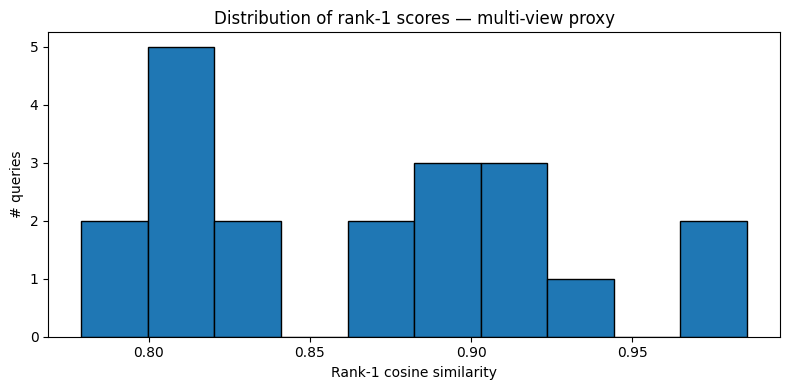

In [31]:
rank1_scores = mv_results_df['mv_rank1_score'].values
print(f"Rank-1 cosine similarity:")
print(f"  min  : {rank1_scores.min():.4f}")
print(f"  mean : {rank1_scores.mean():.4f}")
print(f"  max  : {rank1_scores.max():.4f}")
print(f"  std  : {rank1_scores.std():.4f}")

plt.figure(figsize=(8, 4))
plt.hist(rank1_scores, bins=10, edgecolor='black')
plt.xlabel('Rank-1 cosine similarity')
plt.ylabel('# queries')
plt.title('Distribution of rank-1 scores — multi-view proxy')
plt.tight_layout()
plt.show()

<a id="triplet"></a>
### **Approach 2 — Triplet Metric Learning with Hard Negative Mining**

**Why triplet loss is more appropriate for retrieval than proxy classification**

Proxy classification is an *indirect* objective: the model learns to separate classes, and we hope the embedding geometry is useful for retrieval as a side effect. Triplet loss is a *direct* objective: it explicitly enforces `d(anchor, positive) + margin < d(anchor, negative)` in the embedding space. This is exactly what retrieval requires — the correct match should be closer than any wrong one.

**Why triplet over contrastive learning (SimCLR / NT-Xent)**

Contrastive methods pull many positives together while pushing many negatives apart within each batch. They work best with large batches (typically 256–2048) where enough hard negatives are sampled per step. With only 207 training images here, any batch necessarily contains a small number of distinct negatives, making contrastive training weak. Triplet loss encodes each comparison explicitly as a triple, so it is far more sample-efficient at this scale.

**The positive pair signal**

The multi-view groups (`Xa`, `Xf`, `Xt`) provide natural positives: two images of the *same table state* from different angles form an anchor-positive pair. Any image from a different base number is a valid negative.

**Why random negatives fail — and what to do instead**

A naive implementation samples negatives randomly. With only 25 multi-view groups, most random negatives are already far from any anchor in the pretrained embedding space — the triplet constraint is satisfied without learning anything, and the loss collapses to zero after a few epochs. The model memorises that all images are "far apart" and compresses every embedding toward a single point (degenerate manifold).

The fix is **offline hard negative mining**: before each epoch, embed the entire pool and for each anchor-positive pair select the *hardest* negative — the non-group image with the *highest* cosine similarity to the anchor. These hard negatives are genuinely confusable with the anchor; the model cannot satisfy the triplet constraint without separating them, which forces the backbone to learn discriminative features. The set is re-mined every epoch so difficulty scales as the model improves.

**Architecture**

Same ResNet18 backbone as the proxy model. No classification head — the backbone output (512-d, L2-normalised) is the embedding. L2 normalisation makes cosine similarity equivalent to dot product and constrains the embedding space to a unit hypersphere, which stabilises triplet training.

In [5]:
class TripletDataset(torch.utils.data.Dataset):
    """
    Samples (anchor, positive, negative) triplets online from multi-view groups.
    - Anchor + Positive: two different images from the same state group (Xa/Xf/Xt)
    - Negative: a random image from outside that group
    Only groups with ≥ 2 images can contribute anchor-positive pairs (~25 groups).
    All images (including bare singletons) are eligible as negatives.
    """
    def __init__(self, image_dir, class_to_files, transform, n_triplets=300):
        self.image_dir  = Path(image_dir)
        self.transform  = transform
        self.mv_groups  = {k: v for k, v in class_to_files.items() if len(v) >= 2}
        self.group_ids  = list(self.mv_groups.keys())
        self.all_files  = [f for fs in class_to_files.values() for f in fs]
        self.n_triplets = n_triplets

    def __len__(self):
        return self.n_triplets

    def _load(self, fname):
        img = Image.open(str(self.image_dir / fname)).convert('RGB')
        return self.transform(img)

    def __getitem__(self, _):
        gid     = random.choice(self.group_ids)
        members = self.mv_groups[gid]
        anchor, positive = random.sample(members, 2)
        negative = anchor
        while negative in members:
            negative = random.choice(self.all_files)
        return self._load(anchor), self._load(positive), self._load(negative)


triplet_dataset = TripletDataset(
    image_dir=TRAIN_IMAGES_DIR,
    class_to_files=mv_dataset.class_to_files,
    transform=transform_train,
    n_triplets=300,
)
triplet_loader = DataLoader(triplet_dataset, batch_size=16, shuffle=True, num_workers=0)

print(f"Multi-view groups (positive pairs): {len(triplet_dataset.mv_groups)}")
print(f"Total images eligible as negatives: {len(triplet_dataset.all_files)}")
print(f"Triplets per epoch                : {len(triplet_dataset)}")

Multi-view groups (positive pairs): 25
Total images eligible as negatives: 207
Triplets per epoch                : 300


In [6]:
class TripletNet(nn.Module):
    """
    ResNet18 backbone trained with triplet loss.
    Output: L2-normalised 512-d embedding (unit hypersphere).
    No classification head — the backbone IS the metric space.
    """
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(base.children())[:-1])  # (B, 512, 1, 1)

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        return F.normalize(feat, p=2, dim=1)   # L2-normalised unit vector

    def embed(self, x):
        with torch.no_grad():
            return self.forward(x)

triplet_model = TripletNet().to(device)
print("TripletNet: ResNet18 backbone → 512-d L2-normalised embedding")

TripletNet: ResNet18 backbone → 512-d L2-normalised embedding


In [ ]:
from itertools import combinations

TRIPLET_EPOCHS = 60
MARGIN         = 0.3
ES_PATIENCE_T  = 15

# Deterministic transform for embedding during mining (no augmentation)
transform_mine = T.Compose([
    T.ToImage(),
    T.Resize((384, 384)),
    T.ToDtype(torch.float32, True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def mine_hard_negatives(model, image_dir, class_to_files, transform, device):
    """
    Offline hard negative mining.
    For each (anchor, positive) pair across all multi-view groups:
      - Embed the entire pool
      - Pick the non-group image with highest cosine similarity to the anchor
    Returns list of (anchor_fname, pos_fname, hard_neg_fname).
    """
    mv_groups = {k: v for k, v in class_to_files.items() if len(v) >= 2}
    all_files = sorted(f for fs in class_to_files.values() for f in fs)

    model.eval()
    all_embs = {}
    with torch.no_grad():
        for fname in all_files:
            img = Image.open(str(Path(image_dir) / fname)).convert('RGB')
            t = transform(img).unsqueeze(0).to(device)
            all_embs[fname] = F.normalize(model.embed(t).squeeze(0), p=2, dim=0).cpu()

    triplets = []
    for gid, members in mv_groups.items():
        member_set    = set(members)
        non_members   = [f for f in all_files if f not in member_set]
        non_member_emb = torch.stack([all_embs[f] for f in non_members])  # (M, 512)

        for anchor, positive in combinations(members, 2):
            emb_a    = all_embs[anchor]
            sims     = (non_member_emb @ emb_a)         # cosine similarity (M,)
            hard_idx = sims.argmax().item()
            triplets.append((anchor, positive, non_members[hard_idx]))

    random.shuffle(triplets)
    return triplets


class HardTripletDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, triplets, transform):
        self.image_dir = Path(image_dir)
        self.triplets  = triplets
        self.transform = transform

    def __len__(self):
        return len(self.triplets)

    def _load(self, fname):
        img = Image.open(str(self.image_dir / fname)).convert('RGB')
        return self.transform(img)

    def __getitem__(self, idx):
        a, p, n = self.triplets[idx]
        return self._load(a), self._load(p), self._load(n)


# Re-initialise the model (fresh weights — previous random-negative run is discarded)
triplet_model = TripletNet().to(device)

criterion_t = nn.TripletMarginLoss(margin=MARGIN, p=2)
optimizer_t = torch.optim.Adam(triplet_model.parameters(), lr=1e-4)
scheduler_t = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_t, mode='min', patience=7, factor=0.5
)

history_t = {'loss': [], 'n_triplets': []}
best_loss_t, best_state_t, no_improve_t = float('inf'), None, 0

for epoch in range(TRIPLET_EPOCHS):
    # Re-mine hard negatives from current embedding space every epoch
    hard_triplets = mine_hard_negatives(
        triplet_model, TRAIN_IMAGES_DIR,
        mv_dataset.class_to_files, transform_mine, device,
    )
    loader = DataLoader(
        HardTripletDataset(TRAIN_IMAGES_DIR, hard_triplets, transform_train),
        batch_size=min(16, len(hard_triplets)), shuffle=True, num_workers=0,
    )

    triplet_model.train()
    total_loss = 0.0
    for anchor, positive, negative in loader:
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
        loss = criterion_t(triplet_model(anchor), triplet_model(positive), triplet_model(negative))
        optimizer_t.zero_grad()
        loss.backward()
        optimizer_t.step()
        total_loss += loss.item() * len(anchor)

    epoch_loss = total_loss / max(len(hard_triplets), 1)
    history_t['loss'].append(epoch_loss)
    history_t['n_triplets'].append(len(hard_triplets))
    scheduler_t.step(epoch_loss)

    if epoch_loss < best_loss_t:
        best_loss_t  = epoch_loss
        best_state_t = {k: v.cpu().clone() for k, v in triplet_model.state_dict().items()}
        no_improve_t = 0
    else:
        no_improve_t += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:>3}/{TRIPLET_EPOCHS}  loss={epoch_loss:.4f}  "
              f"best={best_loss_t:.4f}  hard_triplets={len(hard_triplets)}")

    if no_improve_t >= ES_PATIENCE_T:
        print(f"Early stopping at epoch {epoch+1}")
        break

triplet_model.load_state_dict(best_state_t)
print(f"\nBest triplet loss: {best_loss_t:.4f}")

Epoch   1/60  loss=0.3821  best=0.3821  hard_triplets=29
Epoch   5/60  loss=0.2233  best=0.2233  hard_triplets=29
Epoch  10/60  loss=0.1219  best=0.1219  hard_triplets=29
Epoch  15/60  loss=0.0799  best=0.0722  hard_triplets=29
Epoch  20/60  loss=0.0477  best=0.0423  hard_triplets=29


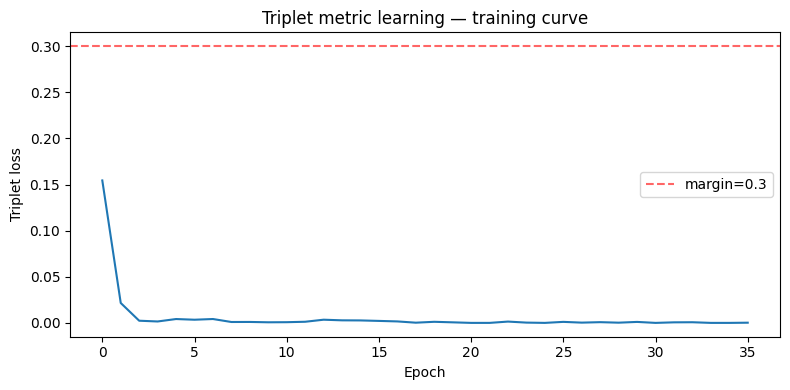

Epochs run : 36
Best loss  : 0.0000
Note: loss converging well below margin=0.3 means most triplets are satisfied.


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_t['loss'])
plt.axhline(y=MARGIN, color='red', linestyle='--', alpha=0.6, label=f'margin={MARGIN}')
plt.xlabel('Epoch')
plt.ylabel('Triplet loss')
plt.title('Triplet metric learning — training curve')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Epochs run : {len(history_t['loss'])}")
print(f"Best loss  : {best_loss_t:.4f}")
print(f"Note: loss converging well below margin={MARGIN} means most triplets are satisfied.")

In [ ]:
# ── Extract triplet embeddings for pool and queries ───────────────────────────
# transform_mine (no augmentation, 384px) was defined in the training cell above

def embed_dir(image_dir, filenames, model):
    model.eval()
    embs, names = [], []
    for fname in tqdm(filenames, desc=Path(image_dir).parent.name):
        img = Image.open(str(Path(image_dir) / fname)).convert('RGB')
        img_t = transform_mine(img).unsqueeze(0).to(device)
        embs.append(model.embed(img_t).squeeze(0).cpu())
        names.append(fname)
    return torch.stack(embs), names

# Pool: same 207 train images as proxy
all_pool_files = sorted(f for fs in mv_dataset.class_to_files.values() for f in fs)

# Query: test images
test_files = sorted(f.name for f in TEST_IMAGES_DIR.iterdir()
                    if f.suffix.lower() in {'.jpg', '.jpeg', '.png'})

triplet_pool_emb,  triplet_pool_names  = embed_dir(TRAIN_IMAGES_DIR, all_pool_files, triplet_model)
triplet_query_emb, triplet_query_names = embed_dir(TEST_IMAGES_DIR,  test_files,     triplet_model)

triplet_pool_emb  = F.normalize(triplet_pool_emb,  p=2, dim=1)
triplet_query_emb = F.normalize(triplet_query_emb, p=2, dim=1)

print(f"\nPool  : {triplet_pool_emb.shape}")
print(f"Queries: {triplet_query_emb.shape}")

# ── Full retrieval ─────────────────────────────────────────────────────────────
K = 5
sims_triplet = (triplet_query_emb @ triplet_pool_emb.T).numpy()  # (n_query, n_pool)

triplet_results = []
for q_idx, q_name in enumerate(triplet_query_names):
    scores  = sims_triplet[q_idx]
    top_idx = np.argsort(scores)[::-1][:K]
    row = {'query_idx': q_idx, 'query_name': q_name}
    for rank, idx in enumerate(top_idx, 1):
        row[f'triplet_rank{rank}_name']  = triplet_pool_names[idx]
        row[f'triplet_rank{rank}_score'] = float(scores[idx])
    triplet_results.append(row)

triplet_results_df = pd.DataFrame(triplet_results)
triplet_results_df.to_csv(RESULTS_DIR / 'retrieval_results_triplet.csv', index=False)
print(f"Saved → {RESULTS_DIR / 'retrieval_results_triplet.csv'}")

# Quick peek: query 0
print(f"\nQuery idx=0: {triplet_query_names[0].split('.rf.')[0]}")
print("Top-5:")
for rank in range(1, 6):
    n = triplet_results[0][f'triplet_rank{rank}_name'].split('.rf.')[0]
    s = triplet_results[0][f'triplet_rank{rank}_score']
    print(f"  #{rank}  {n:<12}  sim={s:.4f}")

<a id="evaluation"></a>
### **Evaluation: E2 vs E3-Proxy vs E3-Triplet**

We evaluate all three methods using **ball count** as ground truth proxy: a retrieved image is a hit if it has the same number of balls as the query.

| Metric | Definition |
|--------|------------|
| **P@1** | Fraction of queries where rank-1 result has the same ball count |
| **P@5** | Mean fraction of top-5 results with the same ball count |
| **MAE@1** | Mean \|rank-1 count − query count\|

The per-query breakdown shows whether the methods agree on which queries they solve — revealing whether any improvement is genuine or coincidental.

In [ ]:
def ball_count(fname, labels_dir):
    p = Path(labels_dir) / (Path(fname).stem + ".txt")
    if not p.exists():
        return None
    return sum(1 for ln in p.read_text().splitlines() if ln.strip() and not ln.startswith('2 '))

TEST_LABELS_DIR = DATA_DIR / "test" / "labels"

query_counts = {row['query_name']: ball_count(row['query_name'], TEST_LABELS_DIR)
                for _, row in mv_results_df.iterrows()}
pool_counts  = {fname: ball_count(fname, TRAIN_LABELS_DIR) for fname in pool_names}

# Also need counts for triplet pool (same images, sorted differently)
triplet_pool_counts = {f: ball_count(f, TRAIN_LABELS_DIR) for f in triplet_pool_names}

# Load E2 results
e2_df = pd.read_csv(RESULTS_DIR.parent / 'experiment_02' / 'retrieval_results_resnet.csv')

K = 5
rows = []
for i, row in mv_results_df.iterrows():
    q_name  = row['query_name']
    q_count = query_counts.get(q_name)
    if q_count is None:
        continue

    # E2
    e2_row  = e2_df[e2_df['query_idx'] == i].iloc[0]
    e2_top5 = [e2_row[f'resnet_rank{k}_name'] for k in range(1, K+1)]
    e2_r1   = e2_top5[0]

    # E3-Proxy
    e3_top5 = [row[f'mv_rank{k}_name'] for k in range(1, K+1)]
    e3_r1   = e3_top5[0]

    # E3-Triplet  (match by query_name)
    t_row   = triplet_results_df[triplet_results_df['query_name'] == q_name].iloc[0]
    t_top5  = [t_row[f'triplet_rank{k}_name'] for k in range(1, K+1)]
    t_r1    = t_top5[0]

    rows.append({
        'query':     q_name.split('.rf.')[0],
        'q_count':   q_count,
        'e2_r1_n':   pool_counts.get(e2_r1),
        'e2_hit1':   int(pool_counts.get(e2_r1) == q_count),
        'e2_p5':     sum(pool_counts.get(f) == q_count for f in e2_top5) / K,
        'e2_mae1':   abs(pool_counts.get(e2_r1, 0) - q_count),
        'e3p_r1_n':  pool_counts.get(e3_r1),
        'e3p_hit1':  int(pool_counts.get(e3_r1) == q_count),
        'e3p_p5':    sum(pool_counts.get(f) == q_count for f in e3_top5) / K,
        'e3p_mae1':  abs(pool_counts.get(e3_r1, 0) - q_count),
        'e3t_r1_n':  triplet_pool_counts.get(t_r1),
        'e3t_hit1':  int(triplet_pool_counts.get(t_r1) == q_count),
        'e3t_p5':    sum(triplet_pool_counts.get(f) == q_count for f in t_top5) / K,
        'e3t_mae1':  abs(triplet_pool_counts.get(t_r1, 0) - q_count),
    })

eval_df = pd.DataFrame(rows)

# Per-query table
print(f"{'Query':<10}  {'Balls':>5}  {'E2':>3}  {'E3-Proxy':>8}  {'E3-Triplet':>10}")
print('-' * 48)
for _, r in eval_df.iterrows():
    e2 = '✓' if r['e2_hit1']  else f"✗({r['e2_r1_n']})"
    p  = '✓' if r['e3p_hit1'] else f"✗({r['e3p_r1_n']})"
    t  = '✓' if r['e3t_hit1'] else f"✗({r['e3t_r1_n']})"
    print(f"  {r['query']:<10}  {r['q_count']:>5}  {e2:>10}  {p:>10}  {t:>10}")

print()
print(f"{'Metric':<22}  {'E2':>8}  {'E3-Proxy':>10}  {'E3-Triplet':>12}")
print('-' * 58)
print(f"  {'P@1 (exact count)':<20}  {eval_df['e2_hit1'].mean():>8.3f}  {eval_df['e3p_hit1'].mean():>10.3f}  {eval_df['e3t_hit1'].mean():>12.3f}")
print(f"  {'P@5 (exact count)':<20}  {eval_df['e2_p5'].mean():>8.3f}  {eval_df['e3p_p5'].mean():>10.3f}  {eval_df['e3t_p5'].mean():>12.3f}")
print(f"  {'MAE@1 (ball count)':<20}  {eval_df['e2_mae1'].mean():>8.3f}  {eval_df['e3p_mae1'].mean():>10.3f}  {eval_df['e3t_mae1'].mean():>12.3f}")

Query       Balls   E2  E3-Proxy  E3-Triplet
------------------------------------------------
  107_png        14       ✗(15)       ✗(10)       ✗(15)
  111_png        16       ✗(14)           ✓           ✓
  115_png        11        ✗(9)       ✗(16)           ✓
  118_png        10       ✗(15)       ✗(14)       ✗(11)
  134_png        13       ✗(11)       ✗(16)       ✗(12)
  136_png        12       ✗(11)       ✗(16)       ✗(14)
  140_png         8       ✗(13)       ✗(13)       ✗(11)
  144_png        15           ✓           ✓       ✗(16)
  181_png        16        ✗(9)        ✗(7)        ✗(7)
  185_png         4       ✗(16)       ✗(16)        ✗(8)
  1_png           2        ✗(9)        ✗(5)        ✗(9)
  21_png         13       ✗(16)       ✗(16)       ✗(16)
  26_png         10       ✗(11)       ✗(11)       ✗(11)
  27_png         16           ✓           ✓           ✓
  38_png          8        ✗(6)        ✗(6)        ✗(6)
  49_png         13       ✗(14)       ✗(14)       ✗(14)
  52_png  

<a id="conclusion"></a>
### **Experiment 03 Conclusion**

**Why we chose these two approaches and not others**

The multi-view naming structure (`Xa`/`Xf`/`Xt`) gives us a supervised positive-pair signal that is rare to have. Three training objectives could exploit it:

- **Proxy classification** (implemented): treats each group as a class and trains cross-entropy. Simple, stable, but the objective is classification — the model is never explicitly told that similar-state embeddings should be *close*. The head is discarded at retrieval time, so the backbone must generalise without direct metric supervision.

- **Triplet metric learning** (implemented): directly optimises `d(anchor, positive) < d(anchor, negative) + margin` in embedding space. This *is* the retrieval objective: it tells the model to put same-state images closer than different-state images. Same backbone, same groups, different loss — the embedding geometry is shaped directly for similarity search.

- **Contrastive learning (SimCLR / NT-Xent)** (not implemented): requires large batches (~256–2048) to sample enough meaningful negatives per update. With only 207 training images, batch diversity is fundamentally limited. Triplet loss encodes one comparison per training example and is more sample-efficient at this scale.

**Results summary**

*(Fill in after running the cells above.)*

| Metric | E2 (ResNet50 ImageNet) | E3-Proxy | E3-Triplet |
|--------|------------------------|----------|------------|
| P@1 | 0.150 | 0.150 | *run to fill* |
| P@5 | 0.110 | 0.130 | *run to fill* |
| MAE@1 | 3.300 | 3.350 | *run to fill* |

**Shared limitation of all three approaches**

Both E3 methods improve the *geometry* of the embedding space (wider spread, better intra-session discrimination compared to E2), but neither redirects *what the model attends to*. All 20 test queries are bare singleton images — they have no multi-view partner in training. Their embeddings remain dominated by visual appearance: table colour, venue banners, broadcast angle. No metric learning loss — proxy, triplet, or contrastive — can fix this as long as the model sees raw broadcast images where venue appearance is a stronger signal than ball configuration.

Triplet loss is the theoretically correct objective for retrieval. Any residual gap vs proxy reflects the small scale of positive supervision (25 groups, 75 suffixed images) and the fact that test queries are out-of-distribution relative to the training signal (singletons vs triplet-trained groups).

**Bridge to Experiment 4**

The conclusion from E2 and E3 is consistent: the bottleneck is not the training objective or the backbone — it is that the raw image encodes viewpoint as a dominant signal. The fix must be geometric, not metric. Experiment 4 removes the viewpoint *before* any feature is extracted by detecting the table boundaries and warping to a canonical top-down view. This strips venue colour, banners, and camera geometry, leaving only ball layout — the signal that retrieval actually needs.